        date  shop  product_id   qty
0 2026-01-01  Lviv         101  10.0
1 2026-01-01  Kyiv         102  15.0
2 2026-01-02  Lviv         101   NaN
3 2026-01-02  Kyiv         101   8.0
4 2026-01-03  Lviv         102  12.0
   product_id        name  price category
0         101       Latte     60    Drink
1         102  Cappuccino     55    Drink


,date,revenue,rolling_mean,yest_rev,growth_prc,diff
2,2026-01-03,1320.0,1295.0,1140.0,15.789474,-25.0


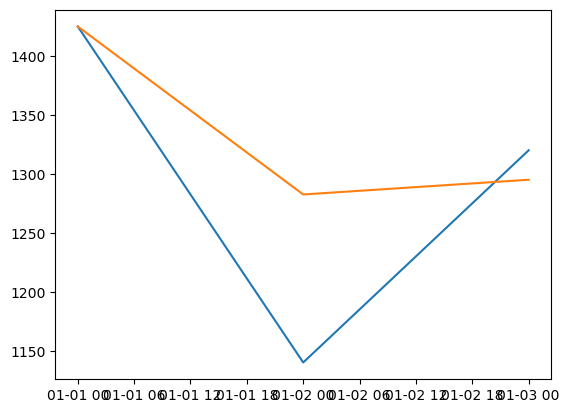

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Таблиця продажів (є пропуски в кількості)
sales = pd.DataFrame({
    'date': pd.to_datetime(['2026-01-01', '2026-01-01', '2026-01-02', '2026-01-02', '2026-01-03', '2026-01-03']),
    'shop': ['Lviv', 'Kyiv', 'Lviv', 'Kyiv', 'Lviv', 'Kyiv'],
    'product_id': [101, 102, 101, 101, 102, 101],
    'qty': [10, 15, np.nan, 8, 12, np.nan]
})

# 2. Довідник товарів
products = pd.DataFrame({
    'product_id': [101, 102],
    'name': ['Latte', 'Cappuccino'],
    'price': [60, 55],
    'category': ['Drink', 'Drink']
})

print(sales.head(5))
print(products.head(5))
sales.isna().sum()
sales['qty'] = sales['qty'].fillna(np.nanmedian(sales['qty']))
df = pd.merge(sales, products, on='product_id', how='left')
df['revenue'] = df['price'] * df['qty']
df

df.pivot_table(index='name',columns='shop', values='qty',aggfunc='sum')

daily_rev = df.groupby('date')['revenue'].sum().reset_index()
daily_rev

daily_rev['rolling_mean'] = daily_rev['revenue'].rolling(window=3, min_periods=1).mean()
daily_rev

plt.plot(daily_rev['date'], daily_rev['revenue'])
plt.plot(daily_rev['date'], daily_rev['rolling_mean'])






In [35]:
daily_rev['yest_rev'] = daily_rev['revenue'].shift(1).fillna(0)
daily_rev['growth_prc'] = daily_rev['revenue'].pct_change() * 100

daily_rev['diff'] = daily_rev['rolling_mean'] - daily_rev['revenue']

daily_rev[daily_rev['diff'] < 0]
daily_rev

,date,revenue,rolling_mean,yest_rev,growth_prc,diff
0,2026-01-01,1425.0,1425.0,0.0,NaN,0.0
1,2026-01-02,1140.0,1282.5,1425.0,-20.000000,142.5
2,2026-01-03,1320.0,1295.0,1140.0,15.789474,-25.0


In [1]:
import pandas as pd

# Отримуємо "незручну" таблицю
bad_df = pd.DataFrame({
    'shop': ['Lviv', 'Kyiv'],
    '2026-01-01': [5000, 7000],
    '2026-01-02': [5500, 6800],
    '2026-01-03': [6000, 7200]
})

In [3]:
bad_df
tidy_df = bad_df.melt(id_vars='shop', var_name='date', value_name='revenue')

In [4]:
tidy_df

,shop,date,revenue
0,Lviv,2026-01-01,5000
1,Kyiv,2026-01-01,7000
2,Lviv,2026-01-02,5500
3,Kyiv,2026-01-02,6800
4,Lviv,2026-01-03,6000
5,Kyiv,2026-01-03,7200


In [6]:
tidy_df['date'] = pd.to_datetime(tidy_df['date'])

In [9]:
tidy_df['roling_avg'] = tidy_df.groupby('shop')['revenue'].transform(lambda x: x.rolling(2, min_periods=1).mean())